In [33]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
url =r"https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"

In [35]:
df = pd.read_csv(url)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [36]:
from sklearn.linear_model import LinearRegression 

In [37]:
lm = LinearRegression()
lm

LinearRegression()

In [38]:
X = df[['highway-mpg']]
Y = df[['price']]
lm.fit(X,Y)

LinearRegression()

In [39]:
Yhat = lm.predict(X)
Yhat[0:5]

array([[16236.50464347],
       [16236.50464347],
       [17058.23802179],
       [13771.3045085 ],
       [20345.17153508]])

In [40]:
lm.intercept_

array([38423.30585816])

In [41]:
lm.coef_

array([[-821.73337832]])

In [42]:
lm1 = LinearRegression()
lm1

LinearRegression()

In [43]:
X = df[['engine-size']]
Y = df[['price']]
lm1.fit(X,Y)

LinearRegression()

In [44]:
yhat1 = lm1.predict(X)
yhat1[0:5]

array([[13728.4631336 ],
       [13728.4631336 ],
       [17399.38347881],
       [10224.40280408],
       [14729.62322775]])

In [45]:
lm1.intercept_

array([-7963.33890628])

In [46]:
lm1.coef_

array([[166.86001569]])

In [47]:
lim2 = LinearRegression()
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
lim2.fit(Z, df[['price']])

LinearRegression()

In [48]:
lim2.intercept_

array([-15806.62462633])

In [49]:
lim2.coef_

array([[53.49574423,  4.70770099, 81.53026382, 36.05748882]])

In [50]:
lm3 = LinearRegression()
W = df[["normalized-losses", "highway-mpg"]]
lm3.fit(W, df[["price"]])

LinearRegression()

In [51]:
lm3.intercept_

array([38201.31327246])

In [52]:
lm3.coef_

array([[   1.49789586, -820.45434016]])

(0.0, 48174.475644013844)

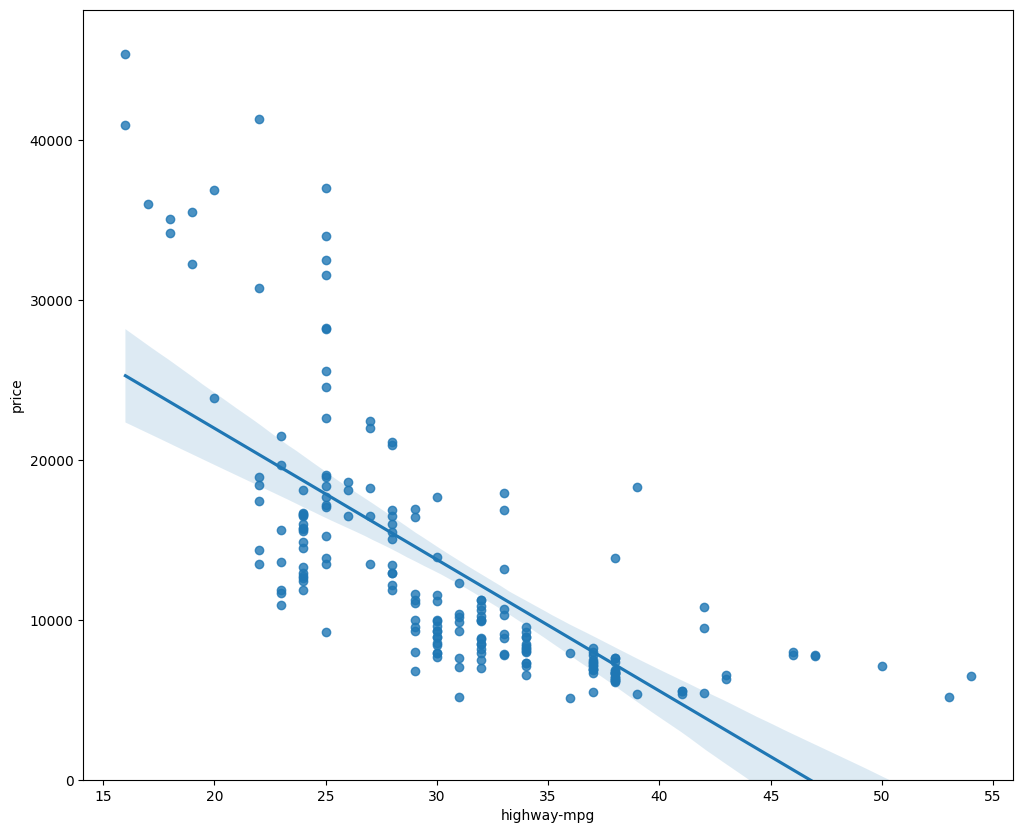

In [53]:
plt.figure(figsize=(12,10))
sns.regplot(x = "highway-mpg", y="price", data = df)
plt.ylim(0,)

In [54]:
df[["peak-rpm", "highway-mpg", "price"]].corr()

,peak-rpm,highway-mpg,price
peak-rpm,1.000000,-0.058598,-0.101616
highway-mpg,-0.058598,1.000000,-0.704692
price,-0.101616,-0.704692,1.000000


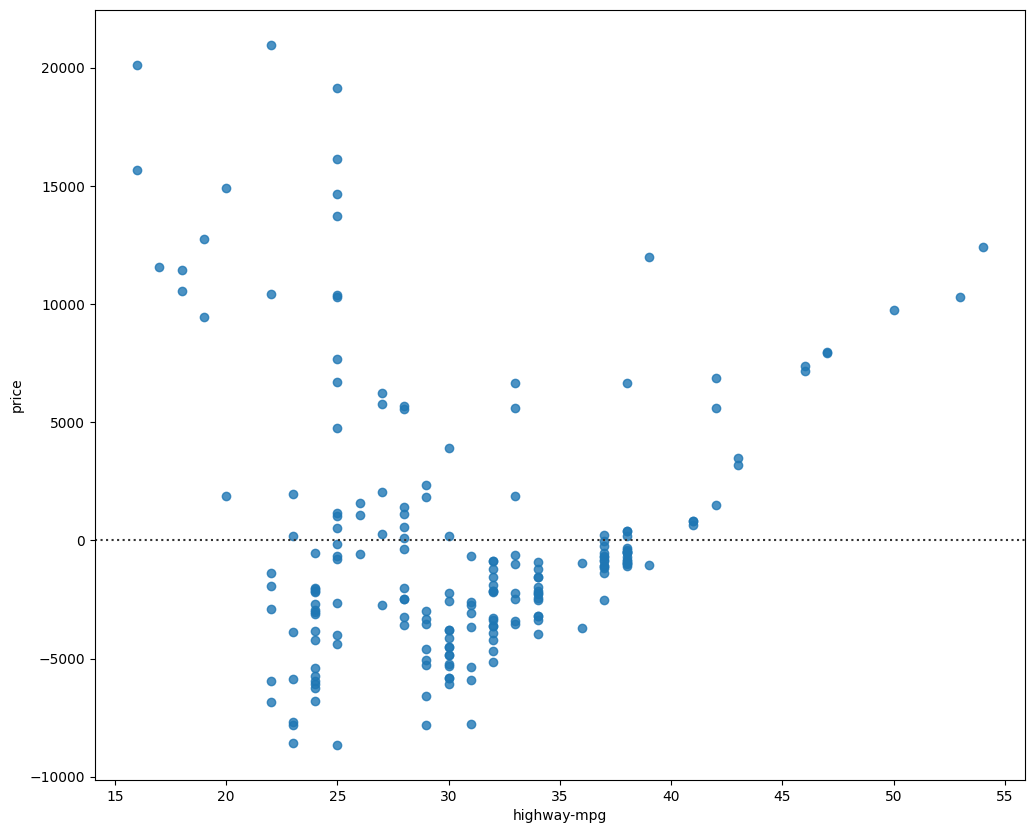

In [55]:
plt.figure(figsize=(12,10))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

In [56]:
Y_hat = lim2.predict(Z)
Y_hat[0:5]

array([[13699.11161184],
       [13699.11161184],
       [19051.65470233],
       [10620.36193015],
       [15521.31420211]])

C:\Users\Mohammed Arfath\AppData\Local\Temp\ipykernel_8344\3488425783.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
C:\Users\Mohammed Arfath\AppData\Local\Temp\ipykernel_8344\3488425783.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

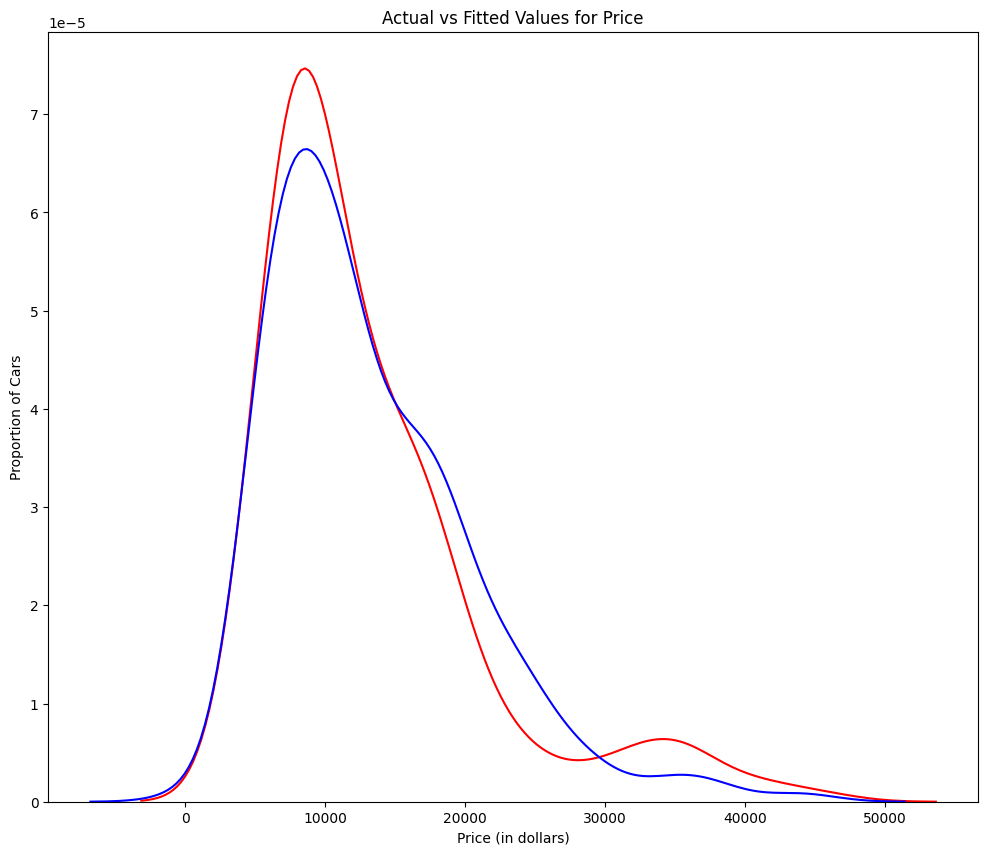

In [57]:
plt.figure(figsize=(12, 10))


ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

In [58]:
x = df['highway-mpg']
y = df['price']

In [59]:
f = np.polyfit(x,y,3)
p=np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


In [60]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

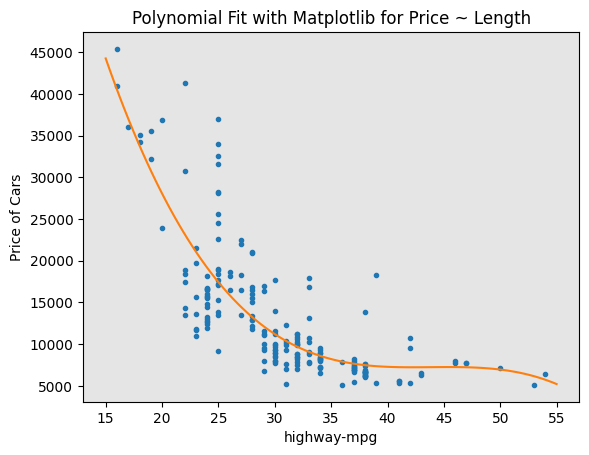

In [61]:
PlotPolly(p, x, y, 'highway-mpg')

In [62]:
np.polyfit(x,y,3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

In [64]:
f1 = np.polyfit(x,y,11)
p1 = np.poly1d(f1)
print(p1)

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


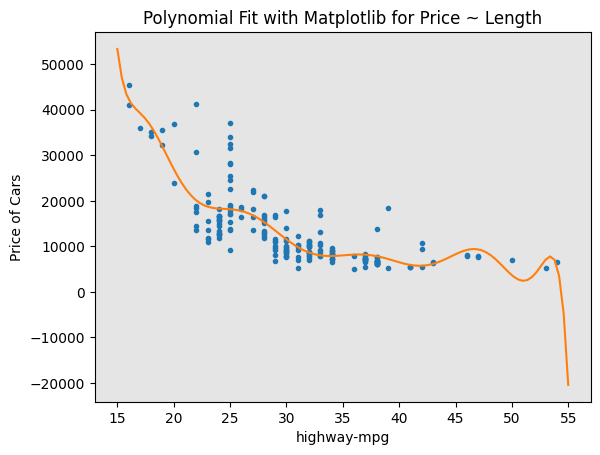

In [66]:
PlotPolly(p1,x,y,'highway-mpg')

In [67]:
from sklearn.preprocessing import PolynomialFeatures

In [68]:
pr = PolynomialFeatures(degree = 2)
pr

PolynomialFeatures()

In [70]:
Z

,horsepower,curb-weight,engine-size,highway-mpg
0,111.0,2548,130,27
1,111.0,2548,130,27
2,154.0,2823,152,26
3,102.0,2337,109,30
4,115.0,2824,136,22
...,...,...,...,...
196,114.0,2952,141,28
197,160.0,3049,141,25
198,134.0,3012,173,23
199,106.0,3217,145,27


In [72]:
Z_pr = pr.fit_transform(Z)

In [73]:
Z.shape

(201, 4)

In [74]:
Z_pr.shape

(201, 15)

In [76]:
print(Z_pr)

[[1.0000e+00 1.1100e+02 2.5480e+03 ... 1.6900e+04 3.5100e+03 7.2900e+02]
 [1.0000e+00 1.1100e+02 2.5480e+03 ... 1.6900e+04 3.5100e+03 7.2900e+02]
 [1.0000e+00 1.5400e+02 2.8230e+03 ... 2.3104e+04 3.9520e+03 6.7600e+02]
 ...
 [1.0000e+00 1.3400e+02 3.0120e+03 ... 2.9929e+04 3.9790e+03 5.2900e+02]
 [1.0000e+00 1.0600e+02 3.2170e+03 ... 2.1025e+04 3.9150e+03 7.2900e+02]
 [1.0000e+00 1.1400e+02 3.0620e+03 ... 1.9881e+04 3.5250e+03 6.2500e+02]]


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [78]:
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias = False)), ('model', LinearRegression())]

In [79]:
pipe = Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [80]:
Z = Z.astype(float)
pipe.fit(Z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [81]:
ypipe = pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

In [83]:
Input2 = [('StandardSclaer', StandardScaler()), ('model', LinearRegression())]

In [85]:
pipe2 = Pipeline(Input2)
pipe2.fit(Z,y)
ypipe2 = pipe.predict(Z)
ypipe2[0:10]

array([13699.11161184, 13699.11161184, 19051.65470233, 10620.36193015,
       15521.31420211, 13869.66673213, 15456.16196732, 15974.00907672,
       17612.35917161, 10722.32509097])

In [86]:
pipe2

Pipeline(steps=[('StandardSclaer', StandardScaler()),
                ('model', LinearRegression())])

In [87]:
lm.fit(X, Y)
print('The R-square is', lm.score(X, Y))

The R-square is 0.7609686443622008


In [90]:
from sklearn.metrics import mean_squared_error

In [93]:
mse = mean_squared_error(df['price'], Yhat)
mse

31635042.944639888

In [94]:
lm.fit(Z, df['price'])
print('The R-squared is:', lm.score(Z, df['price']))

The R-squared is: 0.8093562806577457


In [95]:
y_predict = lm.predict(Z)

In [96]:
mse2 = mean_squared_error(y_predict, df['price'])
mse2

11980366.87072649

In [97]:
from sklearn.metrics import r2_score

In [100]:
r_s = r2_score(y, p(x))
r_s

0.674194666390652

In [101]:
mse3 = mean_squared_error(p(x), y)

In [102]:
mse3

20474146.426361218

In [103]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline 

In [108]:
new_input=np.arange(1, 100, 1).reshape(-1, 1)

In [109]:
lm.fit(X, Y)
lm

LinearRegression()

In [110]:
yhat2=lm.predict(new_input)
yhat2[0:5]

C:\Users\Mohammed Arfath\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[-7796.47889059],
       [-7629.6188749 ],
       [-7462.75885921],
       [-7295.89884352],
       [-7129.03882782]])

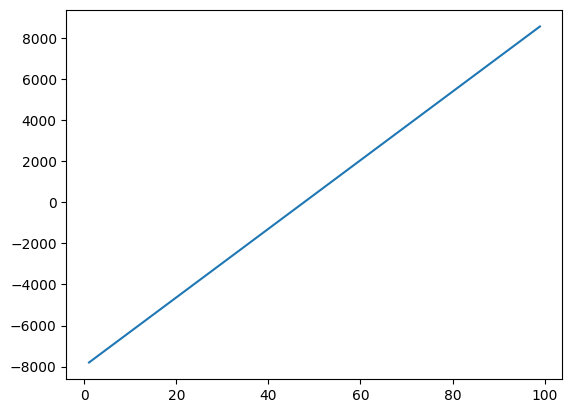

In [112]:
plt.plot(new_input, yhat2)
plt.show()